# The commute you can't see — Snohomish County transit gap

Civic-burden companion, same pattern as `envburden_snohomish.ipynb`: instead of a musical score, the data is [snotrac](https://snotrac.simonhansedasi.com)'s own frequency-weighted transit accessibility and vulnerability model — live, already computed, already shipped as an interactive map for Snohomish County's 575 census block groups.

Panel A shows the two inputs on their own: `vulnerability_index` (who needs transit — elderly, low-income, no-vehicle, unemployed households) and `norm_accessibility` (what service actually reaches them, gravity-weighted by GTFS stop frequency and network distance). Neither alone tells the equity story. Panel B shows `gap_score`, snotrac's own composite — not a metric invented here — and it's where the two independently-scattered layers turn out to line up.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

SNOTRAC_GEOJSON = Path("../snotrac/web/snohomish/data.geojson")
geojson = json.loads(SNOTRAC_GEOJSON.read_text())
features = geojson["features"]
print(f"loaded {len(features)} Snohomish County block groups")

loaded 575 Snohomish County block groups


In [2]:
def bg_rings(geometry):
    """Yield exterior-ring (lon, lat) arrays for a Polygon or MultiPolygon feature.
    Interior holes ignored -- irrelevant for a filled choropleth."""
    coords = geometry["coordinates"]
    polys = [coords] if geometry["type"] == "Polygon" else coords
    for poly in polys:
        yield np.array(poly[0])


# Longitude degrees compress relative to latitude away from the equator;
# correct the axes aspect ratio using this county's actual mean latitude
# instead of hardcoding a projection.
all_lats = np.concatenate(
    [ring[:, 1] for feat in features for ring in bg_rings(feat["geometry"])]
)
LAT_ASPECT = 1 / np.cos(np.radians(all_lats.mean()))


def plot_choropleth(ax, field, cmap="YlOrRd", vmin=None, vmax=None, title=""):
    patches, values = [], []
    for feat in features:
        val = feat["properties"][field]
        if val is None:
            continue
        for ring in bg_rings(feat["geometry"]):
            patches.append(Polygon(ring, closed=True))
            values.append(val)
    coll = PatchCollection(patches, cmap=cmap)
    coll.set_array(np.array(values))
    coll.set_clim(
        vmin if vmin is not None else min(values),
        vmax if vmax is not None else max(values),
    )
    coll.set_edgecolor("white")
    coll.set_linewidth(0.2)
    ax.add_collection(coll)
    ax.autoscale_view()
    ax.set_aspect(LAT_ASPECT)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
    return coll

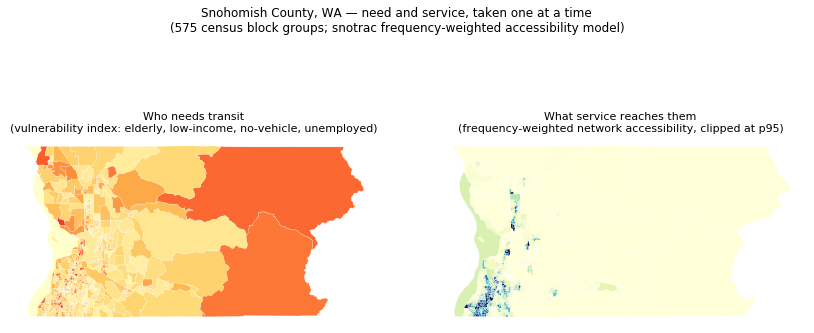

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_choropleth(
    axes[0], "vulnerability_index", cmap="YlOrRd",
    title="Who needs transit\n(vulnerability index: elderly, low-income, no-vehicle, unemployed)",
)
# Accessibility is heavily right-skewed -- ~70% of block groups sit under 0.05,
# with the true max of 1.0 concentrated in a handful of urban-core hubs. A raw
# 0-1 scale renders as almost solid "zero"; clipping at the 95th percentile
# makes the sub-threshold variation visible without hiding the skew (noted below).
accessibility_vals = [f["properties"]["norm_accessibility"] for f in features]
vmax_95 = np.percentile(accessibility_vals, 95)
plot_choropleth(
    axes[1], "norm_accessibility", cmap="YlGnBu", vmax=vmax_95,
    title="What service reaches them\n(frequency-weighted network accessibility, clipped at p95)",
)
fig.suptitle(
    "Snohomish County, WA — need and service, taken one at a time\n"
    "(575 census block groups; snotrac frequency-weighted accessibility model)",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
fig.savefig("transit_gap_layers.png", dpi=150, bbox_inches="tight")
plt.show()

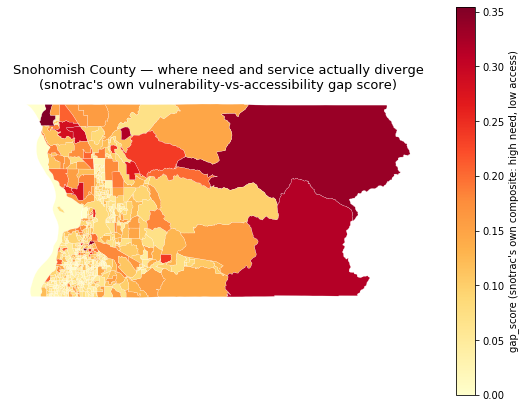

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
coll = plot_choropleth(ax, "gap_score", cmap="YlOrRd")
cbar = fig.colorbar(coll, ax=ax, shrink=0.7)
cbar.set_label("gap_score (snotrac's own composite: high need, low access)")
ax.set_title(
    "Snohomish County — where need and service actually diverge\n"
    "(snotrac's own vulnerability-vs-accessibility gap score)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig("transit_gap_visible.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Self-check: guards against silently loading a stale export or a broken field.
assert 550 < len(features) < 600, f"unexpected block group count: {len(features)}"
assert all(f["properties"]["gap_score"] is not None for f in features), "missing gap_score"
vals = [f["properties"]["gap_score"] for f in features]
assert min(vals) >= 0, "gap_score should be non-negative"
print("self-checks passed")

self-checks passed


## Source & caption notes

- Data: [snotrac](https://snotrac.simonhansedasi.com) — frequency-weighted transit accessibility and vulnerability mapping, Snohomish County, built on Community Transit GTFS + Census ACS. Live interactive version at that link.
- `gap_score` is snotrac's own precomputed composite (vulnerability vs. accessibility mismatch) — not a metric derived in this notebook.
- `norm_accessibility`'s color scale is clipped at the 95th percentile (~0.20) for legibility — the raw 0-1 range is real (about 70% of block groups score under 0.05, and the true max of 1.0 sits at a small number of hub block groups), and the skew itself is part of the story: access isn't spread thin across the county, it's concentrated almost entirely in a few places.
- No new pipeline run for this piece: the geojson is snotrac's existing shipped export, read directly from `../snotrac/web/snohomish/data.geojson`.